# Chapter 5 — Fatband plot of GaAs

A *fatband* plot overlays the orbital character on the band structure:
each band point is drawn with a size proportional to how much a chosen
atomic orbital contributes to that Kohn–Sham state. We use the
`projwfc.x` projections along the band path
(`code/05-bands/gaas.fat.projwfc_up`) together with the band energies
from `gaas.bands.dat.gnu`. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np, re
from pathlib import Path

d = Path('../code/05-bands')

# --- band energies + k-distance from the .gnu (one band per block) ---
blocks, cur = [], []
for line in (d/'gaas.bands.dat.gnu').read_text().splitlines():
    if line.strip(): cur.append([float(x) for x in line.split()[:2]])
    elif cur: blocks.append(np.array(cur)); cur = []
if cur: blocks.append(np.array(cur))
kdist = blocks[0][:, 0]
E = np.array([b[:, 1] for b in blocks])      # (nbnd, nk)
nbnd, nk = E.shape
vbm = E[8].max()                              # 9 occupied bands
E = E - vbm

# --- parse projwfc_up: weights[character][band, k] ---
lines = (d/'gaas.fat.projwfc_up').read_text().splitlines()
# locate the 'lsym' line (two booleans); dims are on the line just before it
il = next(i for i, ln in enumerate(lines) if re.match(r'\s*[TF]\s+[TF]\s*$', ln))
nwfc, nkc, nbc = (int(x) for x in lines[il-1].split())
assert (nkc, nbc) == (nk, nbnd), (nkc, nbc, nk, nbnd)
L = {'S': 's', 'P': 'p', 'D': 'd', 'F': 'f'}
weights, p = {}, il + 1
for _ in range(nwfc):
    hdr = lines[p].split()                    # e.g. '1 1 Ga 4S 1 0 1'
    species, label = hdr[2], hdr[3]
    key = f'{species}-{L[label[-1].upper()]}'
    p += 1
    w = weights.setdefault(key, np.zeros((nbnd, nk)))
    for _ in range(nk * nbnd):
        ik, ib, val = lines[p].split(); p += 1
        w[int(ib)-1, int(ik)-1] += float(val)
print('characters:', sorted(weights))

characters: ['As-p', 'As-s', 'Ga-d', 'Ga-p', 'Ga-s']


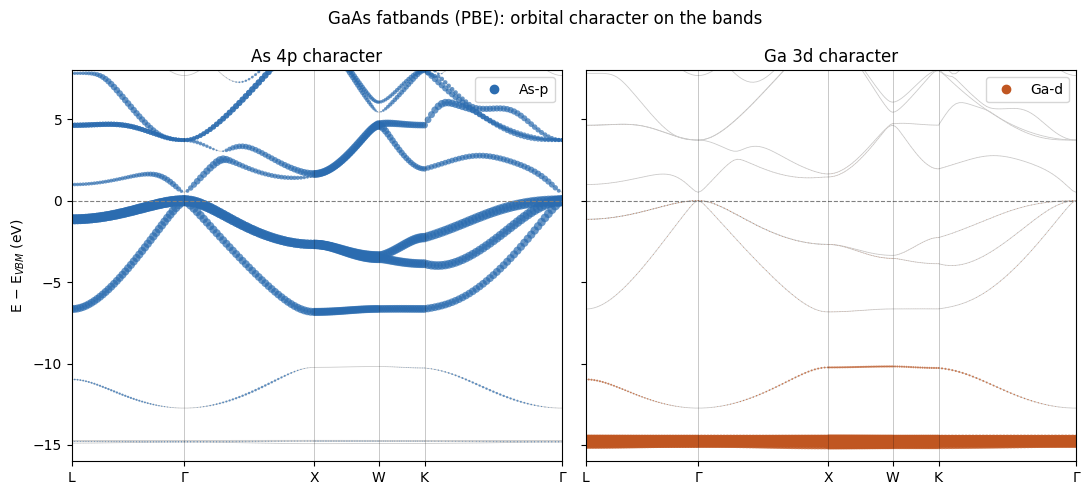

In [2]:
import matplotlib.pyplot as plt

ticks = [0.0, 0.8660, 1.8660, 2.3660, 2.7196, 3.7802]
labels = ['L', 'Γ', 'X', 'W', 'K', 'Γ']

def fatband(ax, key, color, scale=70):
    for ib in range(nbnd):
        ax.scatter(kdist, E[ib], s=weights[key][ib]*scale, color=color,
                   alpha=0.7, edgecolors='none')
    ax.plot([], [], 'o', color=color, label=key)   # legend proxy

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax in axes:
    for b in E:
        ax.plot(kdist, b, color='0.8', lw=0.6, zorder=0)
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    for x in ticks: ax.axvline(x, color='k', lw=0.5, alpha=0.3)
    ax.set_xticks(ticks); ax.set_xticklabels(labels)
    ax.set_xlim(kdist.min(), kdist.max()); ax.set_ylim(-16, 8)

fatband(axes[0], 'As-p', '#2b6cb0'); axes[0].set_title('As 4p character')
fatband(axes[1], 'Ga-d', '#c05621'); axes[1].set_title('Ga 3d character')
axes[0].set_ylabel('E − E$_{VBM}$ (eV)')
for ax in axes: ax.legend(loc='upper right')
fig.suptitle('GaAs fatbands (PBE): orbital character on the bands')
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/05-fatbands.png', dpi=120)
plt.show()

**What you see.** The marker size is the orbital weight $|\langle
\phi_{\text{orb}}|\psi_{n\mathbf{k}}\rangle|^2$. *Left:* **As 4p**
fattens the top of the valence band (−5 eV → VBM) — confirming the PDOS
result that the valence-band maximum is As-p-like. *Right:* **Ga 3d**
fattens only the flat semicore cluster near −14.8 eV and is essentially
absent everywhere else. The fatband is the band-resolved version of the
PDOS from Chapter 6: same projections, now drawn *on the dispersion* so
you can see exactly which bands carry which orbital character.